In [58]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata

In [76]:
# --- Name constants --- #
FLAT = "flat"
X50 = "50x50"
X15 = "15x15"
mapping = {
    FLAT: "Flat",
    X50: "Large-pore",
    X15: "Small-pore",
}

In [77]:
def get_heatmap(filepath):
    values = [] # x y z value
    with open(filepath, "r") as f:
        line_count = 0
        for l in f:
            line_count += 1
            if line_count < 9: continue # First 8 lines are headers
            
            line = l.split()
            row = [float(v) for v in line]
            values.append(row)
    values = np.array(values)
    return values

In [80]:
# --- Visualize all files --- #
directory = "data/samples" # Change directory here
conditions = ["Flat", "Large-pore", "Small-pore"]
initial = [0.1, 0.5, 1, 3, 5, 10]
added = [3.3723, 2.6064, 2.6683, 2.5395]
collection = {}

# Collect heatmaps
for filename in os.listdir(directory):
    if filename.endswith(".txt"):
        filepath = os.path.join(directory, filename)
        condition, x = Path(filepath).stem.split('_')
        condition = mapping[condition.lower()]
        x = float(x)
        if x in initial:
            heatmap = get_heatmap(filepath)
            collection.setdefault(x, {})[condition] = heatmap

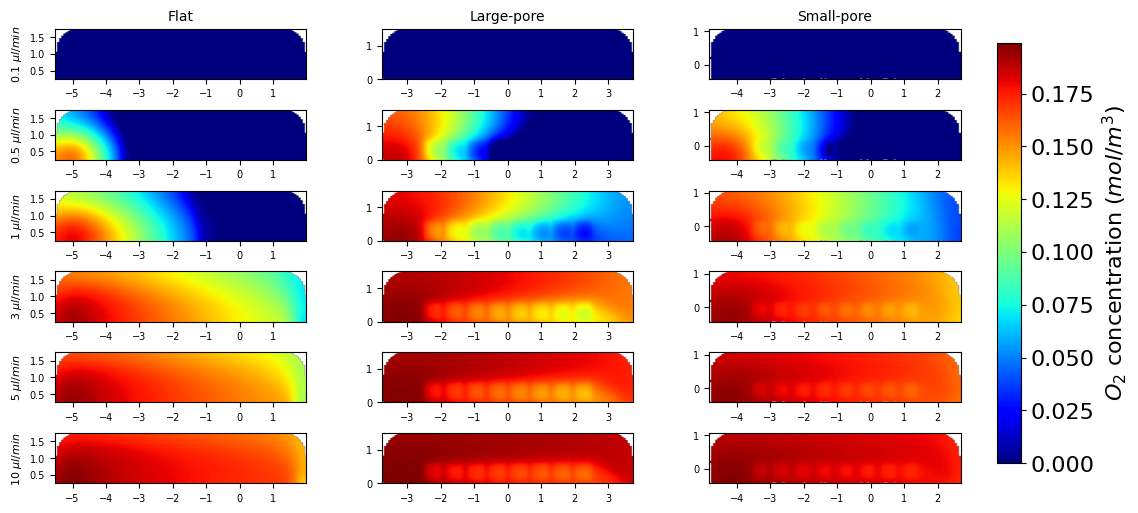

In [81]:
# Build grid: rows = x values (order), cols = conditions
order = initial
# Determine global value range for shared colorbar
all_values = [
    collection[x][cond][:, 3]
    for x in order for cond in conditions
    if x in collection and cond in collection[x]
]
vmin = min(v.min() for v in all_values)
vmax = max(v.max() for v in all_values)

GRID_RES = 120  # adjust for resolution vs. speed tradeoff
matplotlib.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(len(order), 3, figsize=(12, 6))

for row_idx, x in enumerate(order):
    for col_idx, cond in enumerate(conditions):
        ax = axes[row_idx, col_idx]

        if x not in collection or cond not in collection[x]:
            ax.set_visible(False)
            continue

        data = collection[x][cond]
        xs, ys, vals = data[:, 0], data[:, 1], data[:, 3]

        xi = np.linspace(xs.min(), xs.max(), GRID_RES)
        yi = np.linspace(ys.min(), ys.max(), GRID_RES)
        xi, yi = np.meshgrid(xi, yi)

        grid = griddata((xs, ys), vals, (xi, yi), method="linear")

        ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            vmin=vmin,
            vmax=vmax,
            cmap="jet",
            extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        )

        if row_idx == 0:
            ax.set_title(cond, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f"{x} $\\mu l/min$", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_aspect(1.0)

fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap="jet", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="$O_2$ concentration ($mol/m^3$)")

plt.savefig("heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()